# Exploratory Data Analysis

## Imports & Data Import


In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from openpyxl.utils import get_column_letter
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.worksheet.datavalidation import DataValidation
from referral_pathway_analysis import PATHWAYS                # reviewed candidate chains, P001-P010
import sys
from pathlib import Path
import pandas as pd
from odf.opendocument import OpenDocumentSpreadsheet
from odf.style import Style, TableCellProperties, TableColumnProperties, TextProperties
from odf.table import DatabaseRange, DatabaseRanges, Table, TableCell, TableColumn, TableRow
from odf.text import P


In [2]:
DATA_DIR = Path('../data/in/')
RAW_DATA = DATA_DIR / "interviews.json"

In [3]:
print(DATA_DIR)

../data/in


In [4]:
df = pd.read_json(RAW_DATA)

In [5]:
df

,patient_id,interview_transcript
0,P001,"I'm Sarah, 34 years old, and I've been dealing..."
1,P002,"My name's Michael, I'm 42, male, and my Crohn'..."
2,P003,"I'm Emma, 28 years old, diagnosed with Crohn's..."
3,P004,"Robert here, 55 years old, just diagnosed with..."
4,P005,"Lisa, 31, female, diagnosed with Crohn's five ..."
5,P006,"Tom here, 38, dealing with Crohn's for about t..."
6,P007,"I'm Jennifer, 45, diagnosed with Crohn's three..."
7,P008,"David, 29, male, diagnosed with Crohn's at 21 ..."
8,P009,"Rachel, 36, female. Crohn's diagnosis came lat..."
9,P010,"Mark here, 48, diagnosed with Crohn's five yea..."


In [6]:
# Check for nulls
df.isnull().value_counts()

patient_id  interview_transcript
False       False                   50
Name: count, dtype: int64

In [7]:
# Check for duplicates
df.duplicated().value_counts()

False    50
Name: count, dtype: int64

In [8]:
# Check patient_id is unique primary key
df.patient_id.is_unique

True

# EDA for `interview_transcript`

In [9]:
interviews = df.interview_transcript.to_string()

In [10]:
interviews

"0     I'm Sarah, 34 years old, and I've been dealing...\n1     My name's Michael, I'm 42, male, and my Crohn'...\n2     I'm Emma, 28 years old, diagnosed with Crohn's...\n3     Robert here, 55 years old, just diagnosed with...\n4     Lisa, 31, female, diagnosed with Crohn's five ...\n5     Tom here, 38, dealing with Crohn's for about t...\n6     I'm Jennifer, 45, diagnosed with Crohn's three...\n7     David, 29, male, diagnosed with Crohn's at 21 ...\n8     Rachel, 36, female. Crohn's diagnosis came lat...\n9     Mark here, 48, diagnosed with Crohn's five yea...\n10    Jessica, 26, female, diagnosed with Crohn's at...\n11    Paul, 52, male. Just diagnosed with Crohn's la...\n12    Amanda, 33, diagnosed with Crohn's at 25. Fema...\n13    Brian, 41, male. Crohn's diagnosed three years...\n14    My name is Caroline, I'm 37 years old, been de...\n15    I'm Steve, 44 years old, and my Crohn's story ...\n16    I'm Diana, 29, female, and honestly still tryi...\n17    Richard here, 58 years o

In [11]:
wc = WordCloud()

In [12]:
wc.generate(interviews)

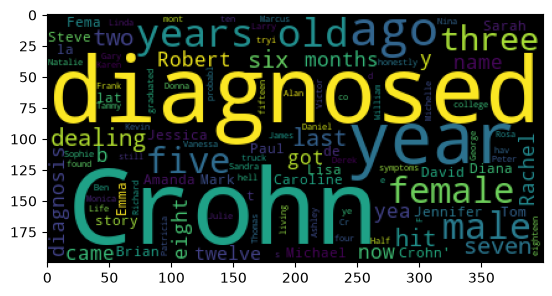

In [13]:
plt.imshow(wc)

# Initial Observations

- Text data on Crohn's disease,
- Diagnosis date, gender (female/male), age, name of patient is topicalised
- Dataset is not labelled so we can do clustering (unsupervised learning) but supervised learning needs labelled target variables

# Export to Excel

We need an audit spreadsheet suitable for non-technical stakeholders to annotate the data and provide a "gold set" of ground truth values for the outcome metrics needed to answer the business questions

In [14]:
GROUND_TRUTH_SPREADSHEET = DATA_DIR / "interviews_ground_truth.xlsx"

df.to_excel(GROUND_TRUTH_SPREADSHEET)

# Build Annotation Spreadsheet

I decided to build a spreadsheet for non-technical stakeholders so that domain experts can create a "gold set" ground truth with labelled data. Currently the `interviews.json` has no labels, so we can only really do unsupervised learning (e.g. clustering like the word cloud) rather than supervised learning (e.g. classification).

For this laborious task, involving mostly boiler-plate code, I started using Claude Code (Opus 4.8 with xhigh effort) in "Explanatory" mode (specifically for software engineers building a system from scratch who need to check every step carefully). 

I copy/pasted the code block from Claude Code, modified it a bit for my notebook workflow, read it for accuracy, then tested it.

The additional spreadsheet columns will probably change in the next iterations, during my manual annotation of 5-10 test cases, so they started out TBA.

**NB** I commented out the following code, so as not to regenerate the spreadsheet over the top of my annotated version, which needed updating (see comments below).

In [ ]:
# Empty annotation columns, in annotation order. Schema is provisional — see docs/SCHEMA.md.
# ANNOTATION_COLS = [
#     "biologic_prescribed", "biologic_taken", "biologic_not_mentioned", "biologic_type",
#     "reasons_for_biologic_prescribed", "reasons_for_biologic_denied",
#     "churn", "incomplete_journey",
#     "treatment_records", "treatment_outcome", "referral_pathway", "evidence_notes",
# ]
# gt = df.assign(**{c: "" for c in ANNOTATION_COLS})

# # Controlled vocabularies -> Excel dropdowns. Keep in sync with docs/SCHEMA.md.
# DROPDOWNS = {
#     '"TRUE,FALSE"': ["biologic_prescribed", "biologic_taken", "biologic_not_mentioned",
#                      "churn", "incomplete_journey"],
#     '"DOCTOR_CHOICE,PATIENT_FEARS,COST,ACCESS,OTHER"': ["reasons_for_biologic_prescribed"],
#     '"NOT_MENTIONED,EXPLICIT_DENIAL,JOURNEY_CUT_OFF,UNKNOWN,OTHER"': ["reasons_for_biologic_denied"],
#     '"SUCCESS,FAILED,PARTIAL,UNKNOWN"': ["treatment_outcome"],
# }

# WRAP_COLS = {"interview_transcript", "treatment_records", "referral_pathway", "evidence_notes"}

# GROUND_TRUTH_XLSX = DATA_DIR / "interviews_ground_truth.xlsx"  # .xlsx — the existing cell's .xslx is a typo
# SHEET = "ground_truth"

# with pd.ExcelWriter(GROUND_TRUTH_XLSX, engine="openpyxl") as writer:
#     gt.to_excel(writer, sheet_name=SHEET, index=False)
#     ws = writer.sheets[SHEET]
#     last_row = len(gt) + 1
#     col = {name: get_column_letter(i + 1) for i, name in enumerate(gt.columns)}

#     ws.freeze_panes = "A2"                                          # header row
#     ws.auto_filter.ref = f"A1:{col[gt.columns[-1]]}{last_row}"      # filter/sort on the header

#     for cell in ws[1]:                                             # bold, shaded header
#         cell.font = Font(bold=True)
#         cell.fill = PatternFill("solid", fgColor="D9E1F2")
#         cell.alignment = Alignment(vertical="center", wrap_text=True)

#     for formula, names in DROPDOWNS.items():                       # dropdown va
#         dv = DataValidation(type="list", formula1=formula, allow_blank=True, showErrorMessage=True)
#         ws.add_data_validation(dv)
#         for name in names:
#             dv.add(f"{col[name]}2:{col[name]}{last_row}")

#     for i, name in enumerate(gt.columns):                          # auto width
#         letter = get_column_letter(i + 1)
#         width = max([len(name)] + [len(str(v)) for v in gt[name]])
#         ws.column_dimensions[letter].width = 60 if name in WRAP_COLS else min(width + 2, 60)
#         if name in WRAP_COLS:
#             for cell in ws[letter][1:]:
#                 cell.alignment = Alignment(wrap_text=True, vertical="top")

# print(f"Wrote {len(gt)} rows x {len(gt.columns)} cols -> {GROUND_TRUTH_XLSX}")

Wrote 50 rows x 14 cols -> ../data/in/interviews_ground_truth.xlsx


# Notes on Data Annotation

- I'm not a domain expert. Ideally at least 3 domain experts would annotate as many journeys as possible to improve the quality of the ground truth set. Then we could create an inter-rater reliability score and create a ground truth version with the highest agreement scored examples.

- After reviewing the first 10 cases, I made some updates to the spreadsheet schema with Claude Code's assistance. The following code keeps my existing annotations and transforms the schema for my next labelling session of an additional set of cases, ensuring there's a class balance for the key output classes: `biologic_taken`, `churn`, `incomplete_journey`

**NB** this first version needed to be updated because the export format was incorrect for .ods format

In [ ]:
# # One-shot: build interviews_ground_truth_v2.ods from the annotated v1 .ods.
# # read -> rename/add/cast/reorder -> fill ONLY empty cells (annotations preserved) -> write.
# # Original file untouched. Works run from the repo root or notebooks/.
# ROOT = Path.cwd()
# ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent      # repo root or notebooks/
# sys.path.insert(0, str(ROOT / "src"))

# DATA_IN = ROOT / "data" / "in"
# src_ods = DATA_IN / "interviews_ground_truth.ods"
# dst_ods = DATA_IN / "interviews_ground_truth_v2.ods"

# # --- scope + candidate fills (review/edit here) ------------------------------------
# FIRST_TEN = [f"P{n:03d}" for n in range(1, 11)]
# SHORTLIST = ["P027", "P035", "P016", "P017", "P032", "P044", "P045", "P048", "P049", "P050"]  # 2 TRUE + 8 FALSE
# REVIEW_CASES = FIRST_TEN + SHORTLIST          # to_review=TRUE for these 20 (drop P027,P035 for the 18-case variant)
# DEMOGRAPHICS = {                              # self-reported, from transcripts
#     "P001": ("female", 34), "P002": ("male", 42), "P003": ("female", 28), "P004": ("male", 55),
#     "P005": ("female", 31), "P006": ("male", 38), "P007": ("female", 45), "P008": ("male", 29),
#     "P009": ("female", 36), "P010": ("male", 48),
# }

# V2_ORDER = [
#     "patient_id", "interview_transcript", "to_review", "churn", "incomplete_journey",
#     "gender", "age", "biologic_prescribed", "biologic_taken", "biologic_not_mentioned",
#     "biologic_type", "reasons_for_biologic_prescribed", "reasons_for_biologic_not_taken",
#     "comorbid_conditions", "treatment_records", "treatment_outcome", "referral_pathway",
#     "evidence_notes",
# ]

# # --- transform ---------------------------------------------------------------------
# df = pd.read_excel(src_ods, engine="odf")
# df = df.rename(columns={"reasons_for_biologic_denied": "reasons_for_biologic_not_taken"})

# for col in ("gender", "age", "comorbid_conditions"):
#     if col not in df.columns:
#         df[col] = pd.NA

# # empty columns arrive as float64 (all-NaN); make text/enum columns object so string
# # assignment doesn't trip pandas 3.0's strict dtype check.  <-- THE FIX
# TEXT_COLS = [
#     "biologic_type", "reasons_for_biologic_prescribed", "reasons_for_biologic_not_taken",
#     "comorbid_conditions", "treatment_records", "treatment_outcome", "referral_pathway",
#     "evidence_notes", "gender", "age",
# ]
# df[TEXT_COLS] = df[TEXT_COLS].astype("object")

# df["to_review"] = df["patient_id"].isin(REVIEW_CASES)

# # fill candidate values ONLY where the cell is currently empty (never overwrite an annotation)
# for pid in FIRST_TEN:
#     row = df["patient_id"] == pid
#     if pid in PATHWAYS:
#         df.loc[row & df["referral_pathway"].isna(), "referral_pathway"] = PATHWAYS[pid]
#     if pid in DEMOGRAPHICS:
#         gender, age = DEMOGRAPHICS[pid]
#         df.loc[row & df["gender"].isna(), "gender"] = gender
#         df.loc[row & df["age"].isna(), "age"] = age

# df = df[V2_ORDER]
# df.to_excel(dst_ods, engine="odf", index=False)
# print(f"Wrote {df.shape[0]} rows x {df.shape[1]} cols -> {dst_ods}")
# print("to_review TRUE:", int(df["to_review"].sum()))

Wrote 50 rows x 18 cols -> /Users/shoutt/projects/mama_health/chronicity/data/in/interviews_ground_truth_v2.ods
to_review TRUE: 20


# "Final" Spreadsheet Export

This is the "final" version of the spreadsheet export, "good enough" for manual review of 20/50 of the cases.

I ran it once from the notebook, then commented it out, so it doesn't overwrite subsequent changes.

In [ ]:
# ROOT = Path.cwd()
# ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent      # repo root or notebooks/
# sys.path.insert(0, str(ROOT / "src"))
# from referral_pathway_analysis import PATHWAYS                # reviewed candidate chains, P001-P010

# DATA_IN = ROOT / "data" / "in"
# src_ods = DATA_IN / "interviews_ground_truth.ods"
# dst_ods = DATA_IN / "interviews_ground_truth_v2.ods"
# SHEET = "ground_truth"

# # One-time bootstrap for to_review (the split flag). After this, to_review IN THE SHEET is the
# # single source of truth; src/splits.py derives validation/holdout by reading it (no hardcoded
# # P* list for the holdout). Re-running preserves an existing to_review column.
# VALIDATION_SEED = [
#     "P001", "P002", "P003", "P004", "P005", "P006", "P007", "P008", "P009", "P010",
#     "P016", "P017", "P027", "P032", "P035", "P044", "P045", "P048", "P049", "P050",
# ]
# DEMOGRAPHICS = {  # self-reported, from transcripts
#     "P001": ("female", 34), "P002": ("male", 42), "P003": ("female", 28), "P004": ("male", 55),
#     "P005": ("female", 31), "P006": ("male", 38), "P007": ("female", 45), "P008": ("male", 29),
#     "P009": ("female", 36), "P010": ("male", 48),
# }
# V2_ORDER = [
#     "patient_id", "interview_transcript", "to_review", "churn", "incomplete_journey",
#     "gender", "age", "biologic_prescribed", "biologic_taken", "biologic_not_mentioned",
#     "biologic_type", "reasons_for_biologic_prescribed", "reasons_for_biologic_not_taken",
#     "comorbid_conditions", "treatment_records", "treatment_outcome", "referral_pathway",
#     "evidence_notes",
# ]
# WRAP_COLS = {"interview_transcript", "treatment_records", "referral_pathway", "evidence_notes"}
# NUMERIC_COLS = {"churn", "incomplete_journey", "biologic_prescribed", "biologic_taken", "biologic_not_mentioned"}

# # --- transform: preserve every annotation, fill only empty cells ---
# df = pd.read_excel(src_ods, engine="odf")
# df = df.rename(columns={"reasons_for_biologic_denied": "reasons_for_biologic_not_taken"})
# for col in ("gender", "age", "comorbid_conditions"):
#     if col not in df.columns:
#         df[col] = pd.NA

# if "to_review" not in df.columns or not df["to_review"].notna().any():
#     df["to_review"] = df["patient_id"].isin(VALIDATION_SEED).map({True: "TRUE", False: "FALSE"})

# # empty columns read from .ods are float64; make text/enum columns object so string writes are safe
# text_cols = [c for c in V2_ORDER if c not in NUMERIC_COLS and c != "patient_id"]
# df[text_cols] = df[text_cols].astype("object")

# for pid, chain in PATHWAYS.items():
#     r = df["patient_id"] == pid
#     df.loc[r & df["referral_pathway"].isna(), "referral_pathway"] = chain
# for pid, (gender, age) in DEMOGRAPHICS.items():
#     r = df["patient_id"] == pid
#     df.loc[r & df["gender"].isna(), "gender"] = gender
#     df.loc[r & df["age"].isna(), "age"] = age
# df = df[V2_ORDER]


# # --- write .ods with column widths + autofilter (the formatting pandas->ods can't do) ---
# def col_letter(n):
#     s = ""
#     while n:
#         n, rem = divmod(n - 1, 26)
#         s = chr(65 + rem) + s
#     return s


# def width_cm(series, name):
#     longest = max([len(str(name))] + [len(str(v)) for v in series if pd.notna(v)])
#     return min(max(longest * 0.20, 2.5), 14.0)  # ~0.2cm/char, capped 2.5-14cm


# doc = OpenDocumentSpreadsheet()
# bold = Style(name="hdr", family="table-cell")
# bold.addElement(TextProperties(fontweight="bold"))
# doc.automaticstyles.addElement(bold)
# wrap = Style(name="wrap", family="table-cell")
# wrap.addElement(TableCellProperties(wrapoption="wrap", verticalalign="top"))
# doc.automaticstyles.addElement(wrap)

# table = Table(name=SHEET)
# for name in df.columns:
#     cs = Style(name=f"co-{name}", family="table-column")
#     cs.addElement(TableColumnProperties(columnwidth=f"{width_cm(df[name], name):.2f}cm"))
#     doc.automaticstyles.addElement(cs)
#     table.addElement(TableColumn(stylename=cs))

# hrow = TableRow()
# for name in df.columns:
#     cell = TableCell(valuetype="string", stylename=bold)
#     cell.addElement(P(text=name))
#     hrow.addElement(cell)
# table.addElement(hrow)

# for _, row in df.iterrows():
#     trow = TableRow()
#     for name in df.columns:
#         v = row[name]
#         if pd.isna(v):
#             trow.addElement(TableCell())
#         elif isinstance(v, (int, float)) and not isinstance(v, bool):
#             trow.addElement(TableCell(valuetype="float", value=float(v)))
#         else:
#             cell = TableCell(valuetype="string", stylename=wrap) if name in WRAP_COLS else TableCell(valuetype="string")
#             cell.addElement(P(text=str(v)))
#             trow.addElement(cell)
#     table.addElement(trow)
# doc.spreadsheet.addElement(table)

# addr = f"{SHEET}.A1:{col_letter(len(df.columns))}{len(df) + 1}"
# ranges = DatabaseRanges()
# ranges.addElement(DatabaseRange(name="__Anonymous_Sheet_DB__0", targetrangeaddress=addr, displayfilterbuttons="true"))
# doc.spreadsheet.addElement(ranges)
# doc.save(str(dst_ods))

# chk = pd.read_excel(dst_ods, engine="odf")
# print("wrote:", dst_ods)
# print("shape:", chk.shape, "| to_review TRUE:", (chk["to_review"].astype(str).str.upper() == "TRUE").sum())

wrote: /Users/shoutt/projects/mama_health/chronicity/data/in/interviews_ground_truth_v2.ods
shape: (50, 18) | to_review TRUE: 20


# Final Notes

This is the "final" stage of the EDA/transform/export steps for creating the minimal testing harness for this use case.

I'll review the latest version of the spreadsheet, and use this to create the test suite to evaluate the live model inference accuracy against the "gold" ground truth. 

A key point is that I won't use the annotated column values for the prompt engineering/few-shot examples, to avoid overfitting. I want the model to only receive the "interview_transcript" values and see if it can output correctly formatted values which fit the schema. Then we'll measure the accuracy against our testing suite output.

I'll use dagster to automate the activation of the orchestration of the test suite, to save time, and check that all the dependencies can be satisfied locally.

Additional one-off transformation scripts created with Claude Code were reviewed in VS Code and outputted to the `sandbox/` folder.